In [1]:
from google.colab import files
uploaded = files.upload()


Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [2]:
import pandas as pd

filename = list(uploaded.keys())[0]     # gets your uploaded file name
df = pd.read_csv(filename)

print("Shape:", df.shape)
df.head()


Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.columns = df.columns.str.strip().str.lower()
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for c in cat_cols:
    df[c] = df[c].astype('category')


In [6]:
df['loan_status'] = df['loan_status'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32581 non-null  int64   
 1   person_income               32581 non-null  int64   
 2   person_home_ownership       32581 non-null  category
 3   person_emp_length           31686 non-null  float64 
 4   loan_intent                 32581 non-null  category
 5   loan_grade                  32581 non-null  category
 6   loan_amnt                   32581 non-null  int64   
 7   loan_int_rate               29465 non-null  float64 
 8   loan_status                 32581 non-null  int64   
 9   loan_percent_income         32581 non-null  float64 
 10  cb_person_default_on_file   32581 non-null  category
 11  cb_person_cred_hist_length  32581 non-null  int64   
dtypes: category(4), float64(3), int64(5)
memory usage: 2.1 MB


In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

from xgboost import XGBClassifier


In [8]:
target = 'loan_status'

X = df.drop(columns=[target])
y = df[target]


In [9]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_cols, categorical_cols


(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'])

In [10]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


In [11]:
model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', XGBClassifier(
        eval_metric='logloss',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4
    ))
])


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [13]:
model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('clf',
                 XGBC...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [14]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9322366805794254
F1 Score: 0.8222794591113973
ROC AUC: 0.93499318280999

Confusion Matrix:
[[6317   52]
 [ 500 1277]]


In [15]:
!pip install shap
import shap


In [16]:
# Extract trained XGBoost model from pipeline
trained_xgb = model.named_steps['clf']

# Preprocess X_test into numeric format
X_test_transformed = model.named_steps['prep'].transform(X_test)

explainer = shap.TreeExplainer(trained_xgb)
shap_values = explainer.shap_values(X_test_transformed)


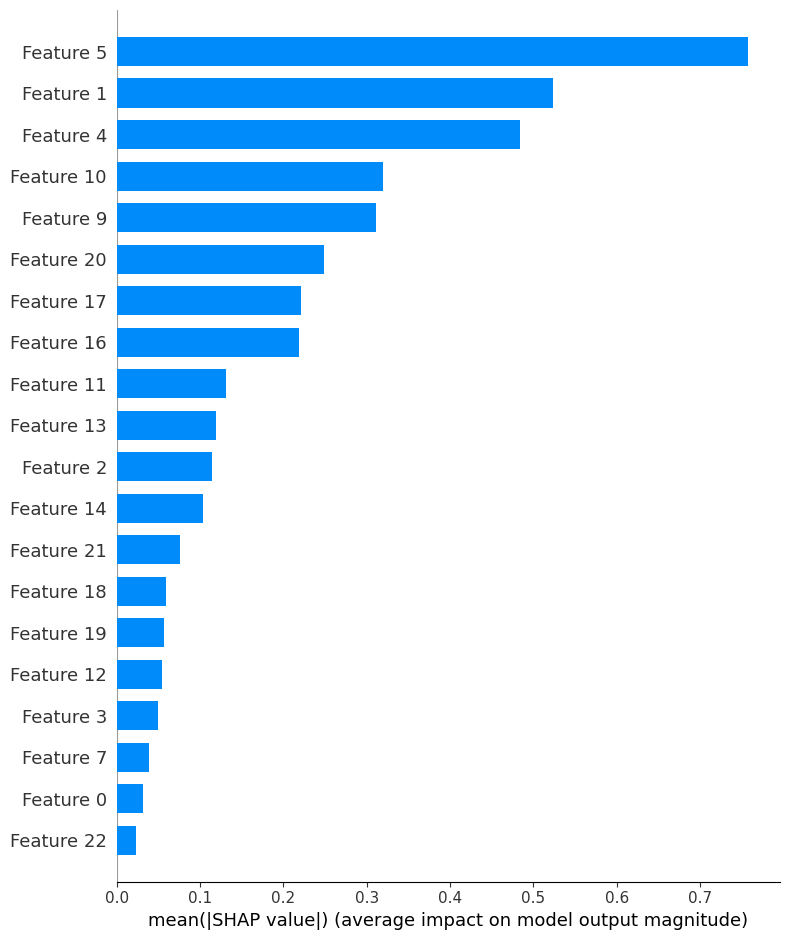

In [17]:
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar")


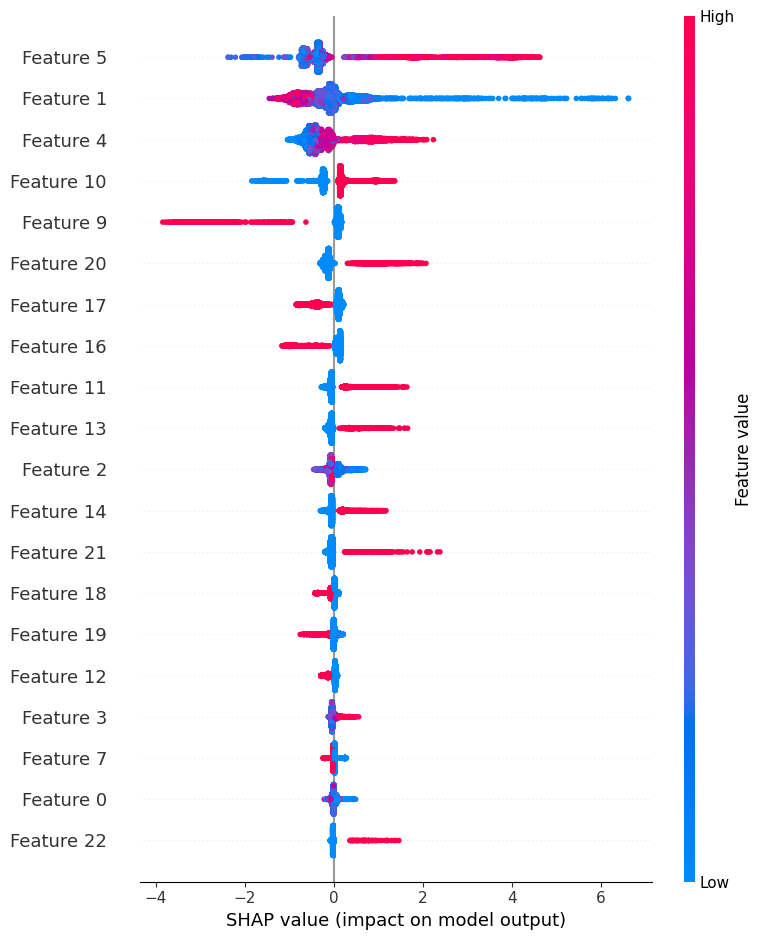

In [18]:
shap.summary_plot(shap_values, X_test_transformed)


In [19]:
# Get numeric feature names
num_features = numeric_cols

# Get one-hot encoded category names
ohe = model.named_steps['prep'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)

# Combine them
all_features = list(num_features) + list(cat_features)

len(all_features), all_features[:10]


(26,
 ['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length',
  'person_home_ownership_MORTGAGE',
  'person_home_ownership_OTHER',
  'person_home_ownership_OWN'])

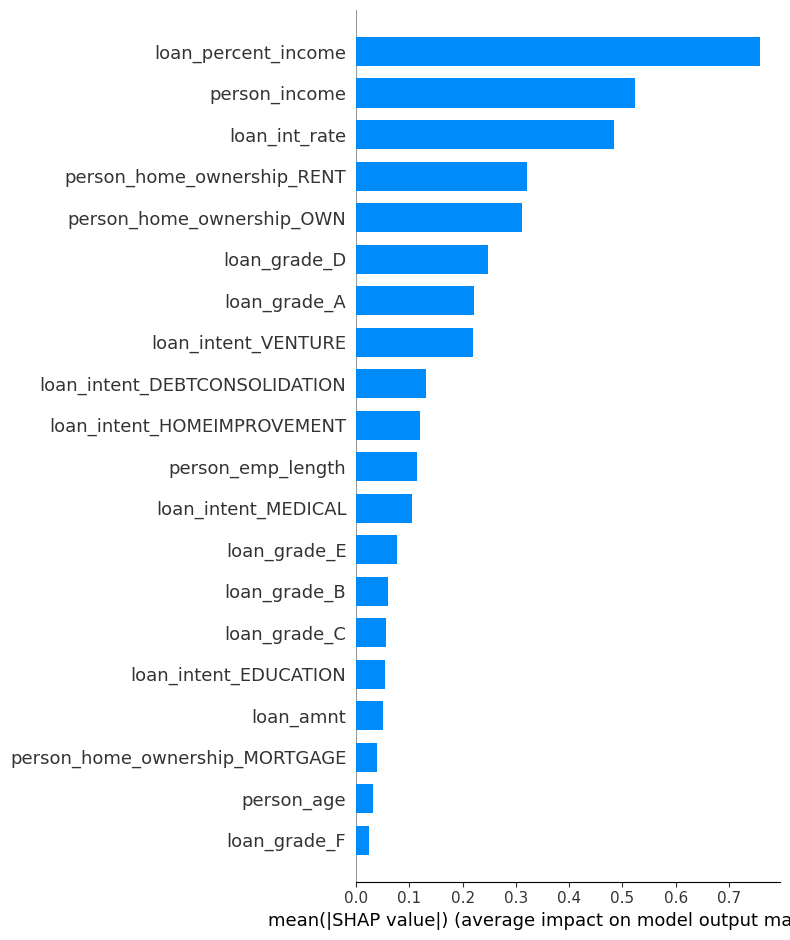

In [20]:
# Convert transformed X_test into a DataFrame with feature names
X_test_df = pd.DataFrame(X_test_transformed, columns=all_features)

shap.summary_plot(shap_values, X_test_df, plot_type="bar")


In [21]:
import pandas as pd
import numpy as np

# Ensure X_test and y_test are in-memory (from previous steps)
# Create index-aligned DataFrames/Series for easy selection
X_test_raw = pd.DataFrame(X_test).reset_index(drop=True)   # untransformed features (readable)
y_test_series = pd.Series(y_test).reset_index(drop=True)

# pick up to 5 defaults (label==1) and 5 non-defaults (label==0)
default_idx = list(y_test_series[y_test_series == 1].index[:5])
nondefault_idx = list(y_test_series[y_test_series == 0].index[:5])

selected_indices = default_idx + nondefault_idx

print("Selected indices (in X_test):", selected_indices)
print("\nSelected labels (index : label):")
print(y_test_series.loc[selected_indices].to_string())

print("\nSelected samples (first rows shown):")
display(X_test_raw.loc[selected_indices])


Selected indices (in X_test): [0, 10, 11, 15, 16, 1, 2, 3, 4, 5]

Selected labels (index : label):
0     1
10    1
11    1
15    1
16    1
1     0
2     0
3     0
4     0
5     0

Selected samples (first rows shown):


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,26,22406,RENT,5.0,PERSONAL,A,2500,6.76,0.11,N,4
10,26,33800,RENT,4.0,PERSONAL,C,13000,13.57,0.38,Y,2
11,22,58170,RENT,1.0,EDUCATION,A,3000,9.07,0.05,N,2
15,25,77000,MORTGAGE,1.0,DEBTCONSOLIDATION,F,7200,18.53,0.09,N,2
16,45,49000,OWN,5.0,MEDICAL,E,24250,19.03,0.49,Y,11
1,29,66500,OWN,4.0,VENTURE,A,12000,6.99,0.18,N,8
2,24,112000,RENT,5.0,DEBTCONSOLIDATION,C,5400,15.27,0.05,Y,4
3,24,40000,RENT,5.0,DEBTCONSOLIDATION,B,5000,12.42,0.13,N,3
4,34,72960,MORTGAGE,1.0,MEDICAL,B,11000,12.21,0.15,N,8
5,29,74004,MORTGAGE,13.0,PERSONAL,B,13000,11.26,0.18,N,6


In [22]:
# Transform the selected readable rows to the numeric matrix expected by the explainer
selected_raw = X_test_raw.loc[selected_indices].reset_index(drop=True)

# Preprocessed numeric matrix (same columns/order as all_features)
selected_transformed = model.named_steps['prep'].transform(selected_raw)

# compute SHAP values for these transformed rows
shap_values_selected = explainer.shap_values(selected_transformed)  # shape: (10, n_features)
print("Computed SHAP values for", selected_transformed.shape[0], "samples and", selected_transformed.shape[1], "features.")


Computed SHAP values for 10 samples and 26 features.


In [25]:
# Corrected: pretty-print local explanations using transformed feature values
import pandas as pd
import numpy as np

# selected_raw (human-readable) and selected_transformed must exist from earlier steps

# Build DataFrame for transformed rows (these match all_features)
selected_transformed_df = pd.DataFrame(selected_transformed, columns=all_features)
y_test_series = pd.Series(y_test).reset_index(drop=True)

n_show = 8  # top contributors to show per loan
for i, idx in enumerate(selected_indices):
    shap_row = shap_values_selected[i]
    transformed_vals = selected_transformed_df.iloc[i].values  # length matches all_features

    df_local = pd.DataFrame({
        'feature': all_features,
        'value_transformed': transformed_vals,
        'shap_value': shap_row
    })

    df_local = df_local.reindex(
        df_local.shap_value.abs().sort_values(ascending=False).index
    ).head(n_show)

    print("\n" + "="*80)
    print(f"Loan index (X_test) = {idx} | True label = {int(y_test_series.loc[idx])}")
    print("- original readable row -")
    display(selected_raw.iloc[i:i+1])

    print("- top SHAP contributors (transformed) -")
    print(df_local.to_string(index=False))



Loan index (X_test) = 0 | True label = 1
- original readable row -


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,26,22406,RENT,5.0,PERSONAL,A,2500,6.76,0.11,N,4


- top SHAP contributors (transformed) -
                    feature  value_transformed  shap_value
        loan_percent_income               0.11   -0.689235
              person_income           22406.00    0.536411
              loan_int_rate               6.76   -0.496076
               loan_grade_A               1.00   -0.304723
 person_home_ownership_RENT               1.00    0.145886
        loan_intent_VENTURE               0.00    0.139196
               loan_grade_D               0.00   -0.134825
loan_intent_HOMEIMPROVEMENT               0.00   -0.126757

Loan index (X_test) = 10 | True label = 1
- original readable row -


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,26,33800,RENT,4.0,PERSONAL,C,13000,13.57,0.38,Y,2


- top SHAP contributors (transformed) -
                       feature  value_transformed  shap_value
           loan_percent_income               0.38    3.819102
    person_home_ownership_RENT               1.00    0.910021
                 person_income           33800.00    0.556777
person_home_ownership_MORTGAGE               0.00    0.267841
     person_home_ownership_OWN               0.00    0.141826
                  loan_grade_D               0.00   -0.103829
                  loan_grade_C               1.00   -0.092810
   loan_intent_HOMEIMPROVEMENT               0.00   -0.092637

Loan index (X_test) = 11 | True label = 1
- original readable row -


...

- top SHAP contributors (transformed) -
                      feature  value_transformed  shap_value
          loan_percent_income               0.13   -0.668590
                loan_int_rate              12.42   -0.387578
loan_intent_DEBTCONSOLIDATION               1.00    0.291604
                 loan_grade_D               0.00   -0.233356
                person_income           40000.00   -0.150319
          loan_intent_VENTURE               0.00    0.140725
   person_home_ownership_RENT               1.00    0.129854
    person_home_ownership_OWN               0.00    0.117319

Loan index (X_test) = 4 | True label = 0
- original readable row -


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
8,34,72960,MORTGAGE,1.0,MEDICAL,B,11000,12.21,0.15,N,8


- top SHAP contributors (transformed) -
                   feature  value_transformed  shap_value
             loan_int_rate              12.21   -0.412601
       loan_percent_income               0.15   -0.344277
             person_income           72960.00   -0.241208
       loan_intent_MEDICAL               1.00    0.231348
person_home_ownership_RENT               0.00   -0.230282
              loan_grade_D               0.00   -0.225738
       loan_intent_VENTURE               0.00    0.133647
              loan_grade_A               0.00    0.129653

Loan index (X_test) = 5 | True label = 0
- original readable row -


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
9,29,74004,MORTGAGE,13.0,PERSONAL,B,13000,11.26,0.18,N,6


- top SHAP contributors (transformed) -
                   feature  value_transformed  shap_value
             loan_int_rate              11.26   -0.348062
             person_income           74004.00   -0.335048
       loan_percent_income               0.18   -0.275944
person_home_ownership_RENT               0.00   -0.210120
       loan_intent_VENTURE               0.00    0.151779
              loan_grade_D               0.00   -0.136630
              loan_grade_A               0.00    0.111130
 person_home_ownership_OWN               0.00    0.095878


In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, confusion_matrix, roc_auc_score

# Ensure X_test_raw, X_test_transformed, y_test_series exist
# If names differ, they were created earlier as:
# X_test_raw = pd.DataFrame(X_test).reset_index(drop=True)
# selected_transformed_df = pd.DataFrame(selected_transformed, columns=all_features)
# For full test set transformed:
X_test_transformed_full = pd.DataFrame(X_test_transformed, columns=all_features)
X_test_raw = pd.DataFrame(X_test).reset_index(drop=True)
y_test_series = pd.Series(y_test).reset_index(drop=True)

# Get model predictions on X_test (already computed earlier but recompute to be safe)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Add everything to a single DataFrame for easy grouping
audit_df = X_test_raw.copy()
audit_df['y_true'] = y_test_series.values
audit_df['y_pred'] = y_pred
audit_df['y_proba'] = y_proba

# Create an income-based sensitive attribute: low/high by median
income_med = audit_df['person_income'].median()
audit_df['income_group'] = np.where(audit_df['person_income'] >= income_med, 'high_income', 'low_income')

# Home ownership is already categorical; ensure consistent labels
audit_df['home_group'] = audit_df['person_home_ownership'].astype(str)

print("Sample counts by group:")
print(audit_df.groupby(['home_group','income_group']).size().unstack(fill_value=0))

# Basic overall stats
print("\nOverall test set size:", audit_df.shape[0])
print("Income median used for split:", income_med)


Sample counts by group:
income_group  high_income  low_income
home_group                           
MORTGAGE             2302        1088
OTHER                  19           6
OWN                   256         391
RENT                 1547        2537

Overall test set size: 8146
Income median used for split: 55000.0


In [27]:
# Helper to compute metrics
def group_metrics(df, group_col, positive_label=1):
    rows = []
    for g, gdf in df.groupby(group_col):
        y_true = gdf['y_true']
        y_pred = gdf['y_pred']
        y_proba = gdf['y_proba']
        # True Positive Rate (Recall for positive class)
        if sum(y_true==positive_label) > 0:
            tpr = recall_score(y_true, y_pred, pos_label=positive_label)
        else:
            tpr = np.nan
        # False Positive Rate
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        prec = precision_score(y_true, y_pred, pos_label=positive_label)
        auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true))>1 else np.nan
        rows.append({'group':g, 'size':len(gdf), 'positives':int(sum(y_true==positive_label)),
                     'tpr':tpr, 'fpr':fpr, 'precision':prec, 'auc':auc})
    return pd.DataFrame(rows)

# Metrics for home_group
home_metrics = group_metrics(audit_df, 'home_group')
print("=== Home ownership group metrics ===")
print(home_metrics.to_string(index=False))

# Metrics for income_group
inc_metrics = group_metrics(audit_df, 'income_group')
print("\n=== Income group metrics ===")
print(inc_metrics.to_string(index=False))

# Compute Equal Opportunity Difference for a chosen pair:
# For home: compare RENT vs OWN (unprivileged vs privileged here—document your choice)
def equal_opportunity_diff(metrics_df, group_a, group_b):
    tpr_a = metrics_df.loc[metrics_df['group']==group_a, 'tpr'].values
    tpr_b = metrics_df.loc[metrics_df['group']==group_b, 'tpr'].values
    if len(tpr_a)==0 or len(tpr_b)==0:
        return np.nan
    return float(tpr_a[0]) - float(tpr_b[0])

eod_home = equal_opportunity_diff(home_metrics, 'RENT', 'OWN')
eod_income = equal_opportunity_diff(inc_metrics, 'low_income', 'high_income')

print(f"\nEqual Opportunity Difference (TPR_RENT - TPR_OWN) = {eod_home:.4f}")
print(f"Equal Opportunity Difference (TPR_low_income - TPR_high_income) = {eod_income:.4f}")


=== Home ownership group metrics ===
   group  size  positives      tpr      fpr  precision      auc
MORTGAGE  3390        429 0.454545 0.007768   0.894495 0.855679
   OTHER    25          6 0.500000 0.052632   0.750000 0.868421
     OWN   647         53 0.981132 0.001684   0.981132 0.999968
    RENT  4084       1289 0.796742 0.009660   0.974383 0.951766

=== Income group metrics ===
      group  size  positives      tpr      fpr  precision      auc
high_income  4124        532 0.631579 0.003341   0.965517 0.913949
 low_income  4022       1245 0.755823 0.014404   0.959225 0.936698

Equal Opportunity Difference (TPR_RENT - TPR_OWN) = -0.1844
Equal Opportunity Difference (TPR_low_income - TPR_high_income) = 0.1242


In [28]:
# We'll compute mean SHAP per feature for each subgroup and show differences for top features
import numpy as np

# If shap_values (full test set) is not yet computed as array for the entire X_test_transformed:
# explainer and trained_xgb should exist; compute if missing:
try:
    _ = shap_values  # from earlier
except NameError:
    shap_values = explainer.shap_values(X_test_transformed)

# Create DataFrame of SHAP values (rows = samples, cols = all_features)
shap_df = pd.DataFrame(shap_values, columns=all_features)
# Attach group labels for joins
shap_df['home_group'] = audit_df['home_group'].values
shap_df['income_group'] = audit_df['income_group'].values

# Select top 8 global features you already identified (or take top 8 by mean abs shap)
global_top = (shap_df.drop(columns=['home_group','income_group']).abs().mean().sort_values(ascending=False).head(8).index.tolist())

print("Top global features used for SHAP comparison:", global_top)

# Compute mean SHAP per group for these features
home_shap_mean = shap_df.groupby('home_group')[global_top].mean().reset_index()
income_shap_mean = shap_df.groupby('income_group')[global_top].mean().reset_index()

print("\n=== Mean SHAP per feature by home_group ===")
print(home_shap_mean.to_string(index=False))

print("\n=== Mean SHAP per feature by income_group ===")
print(income_shap_mean.to_string(index=False))

# Also compute difference (RENT - OWN) for quick signal
if 'RENT' in home_shap_mean['home_group'].values and 'OWN' in home_shap_mean['home_group'].values:
    rent_vals = home_shap_mean[home_shap_mean['home_group']=='RENT'].iloc[0]
    own_vals = home_shap_mean[home_shap_mean['home_group']=='OWN'].iloc[0]
    diff = rent_vals[global_top] - own_vals[global_top]
    print("\n=== (RENT - OWN) mean SHAP difference for top features ===")
    print(diff.to_string())


Top global features used for SHAP comparison: ['loan_percent_income', 'person_income', 'loan_int_rate', 'person_home_ownership_RENT', 'person_home_ownership_OWN', 'loan_grade_D', 'loan_grade_A', 'loan_intent_VENTURE']

=== Mean SHAP per feature by home_group ===
home_group  loan_percent_income  person_income  loan_int_rate  person_home_ownership_RENT  person_home_ownership_OWN  loan_grade_D  loan_grade_A  loan_intent_VENTURE
  MORTGAGE            -0.140715      -0.327335      -0.211265                   -0.345402                   0.100489     -0.045437     -0.115724            -0.044602
     OTHER            -0.116914      -0.242647      -0.010091                   -0.366468                   0.110767      0.191732      0.016615            -0.243471
       OWN             0.080980       0.173383      -0.233110                   -0.452076                  -2.707007      0.013456     -0.057514            -0.154963
      RENT             0.000046       0.083744      -0.110996            

Top features used for plots: ['loan_percent_income', 'person_income', 'loan_int_rate', 'person_home_ownership_RENT', 'person_home_ownership_OWN', 'loan_grade_D', 'loan_grade_A', 'loan_intent_VENTURE']


<Figure size 600x400 with 0 Axes>

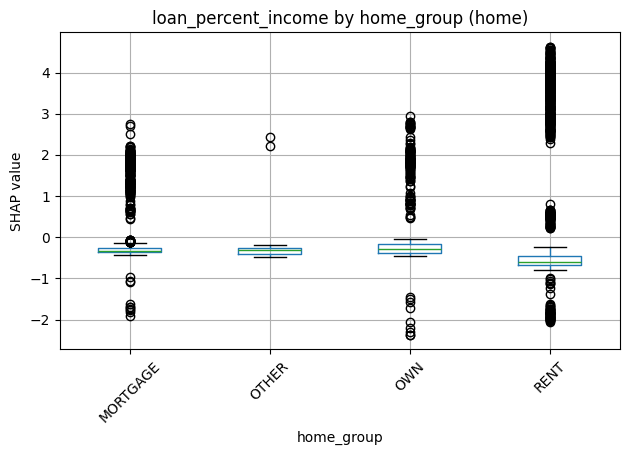

Medians for loan_percent_income by home_group:
home_group
MORTGAGE   -0.329274
OTHER      -0.306829
OWN        -0.287922
RENT       -0.611993


<Figure size 600x400 with 0 Axes>

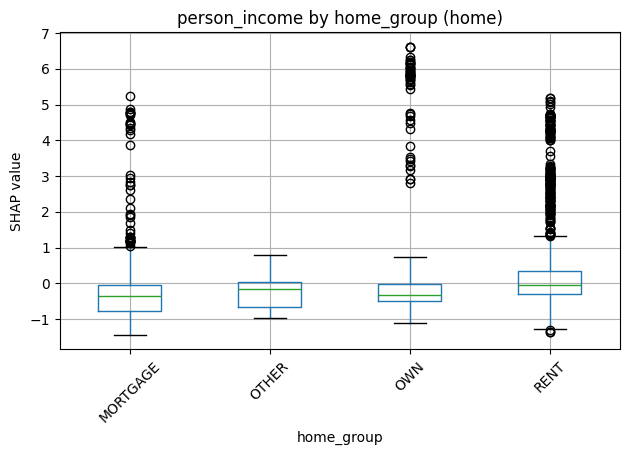

Medians for person_income by home_group:
home_group
MORTGAGE   -0.343920
OTHER      -0.168480
OWN        -0.320821
RENT       -0.044253


<Figure size 600x400 with 0 Axes>

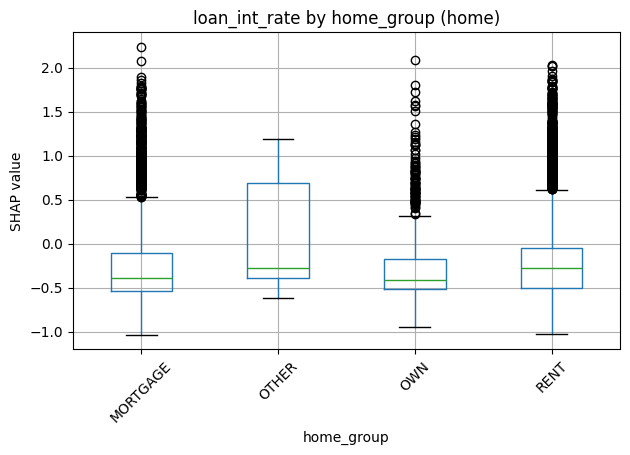

Medians for loan_int_rate by home_group:
home_group
MORTGAGE   -0.386878
OTHER      -0.278887
OWN        -0.414473
RENT       -0.279885


<Figure size 600x400 with 0 Axes>

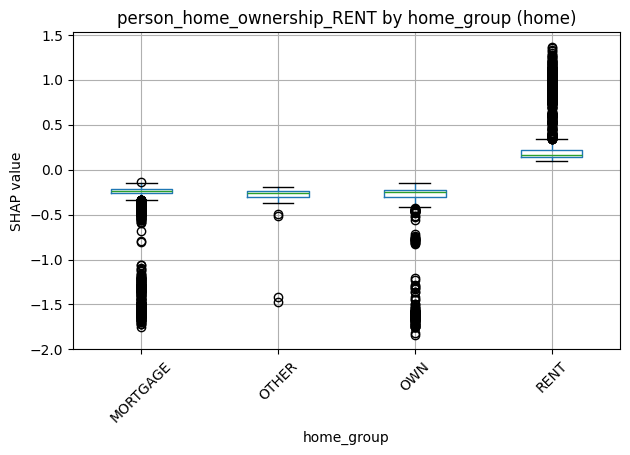

Medians for person_home_ownership_RENT by home_group:
home_group
MORTGAGE   -0.232198
OTHER      -0.254985
OWN        -0.249392
RENT        0.161089


<Figure size 600x400 with 0 Axes>

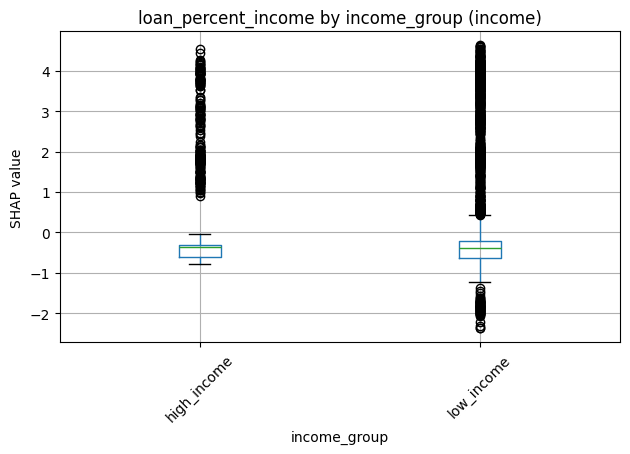

Medians for loan_percent_income by income_group:
income_group
high_income   -0.356384
low_income    -0.394502


<Figure size 600x400 with 0 Axes>

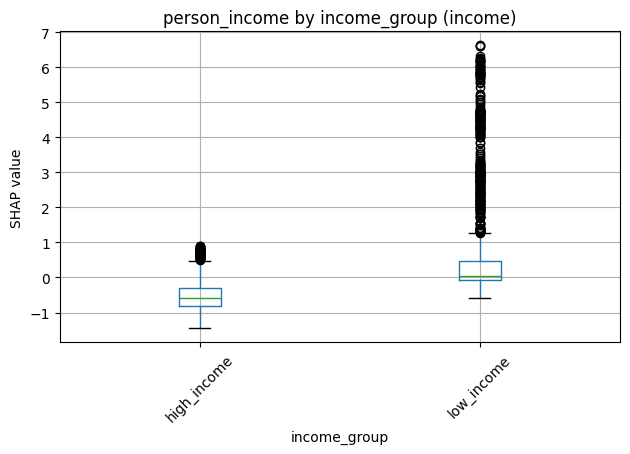

Medians for person_income by income_group:
income_group
high_income   -0.571442
low_income     0.049836


<Figure size 600x400 with 0 Axes>

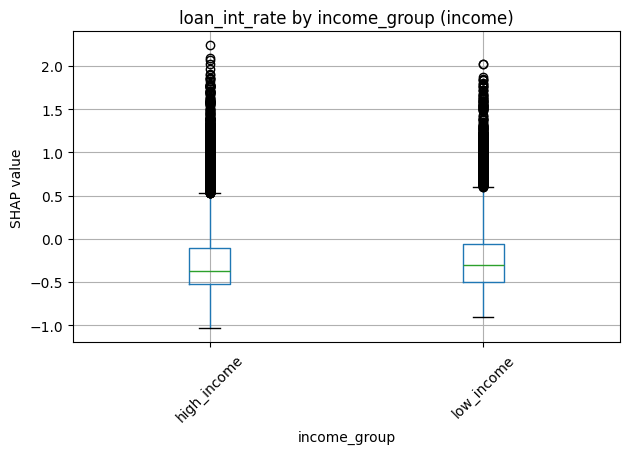

Medians for loan_int_rate by income_group:
income_group
high_income   -0.377684
low_income    -0.303500


<Figure size 600x400 with 0 Axes>

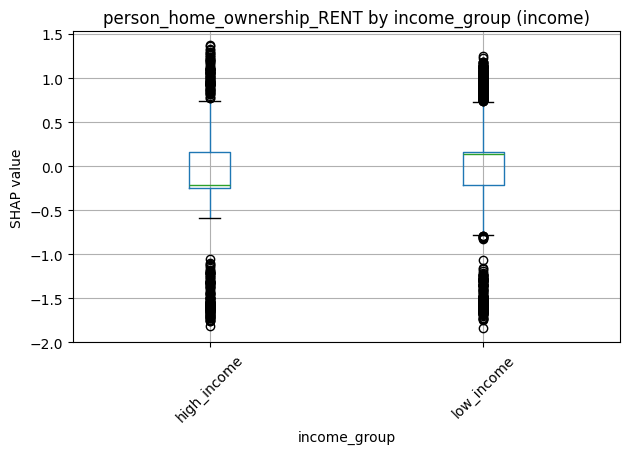

Medians for person_home_ownership_RENT by income_group:
income_group
high_income   -0.217079
low_income     0.139618


In [29]:
# CELL 4
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use global_top from earlier (already computed), otherwise recompute
try:
    global_top
except NameError:
    shap_df = pd.DataFrame(shap_values, columns=all_features)
    global_top = shap_df.abs().mean().sort_values(ascending=False).head(8).index.tolist()

shap_df = pd.DataFrame(shap_values, columns=all_features)
shap_df['home_group'] = audit_df['home_group'].values
shap_df['income_group'] = audit_df['income_group'].values

# Plot function
def plot_shap_box(feature, group_col, title_suffix):
    plt.figure(figsize=(6,4))
    shap_df.boxplot(column=feature, by=group_col, rot=45)
    plt.title(f"{feature} by {group_col} {title_suffix}")
    plt.suptitle('')
    plt.ylabel('SHAP value')
    plt.tight_layout()
    plt.show()
    # print medians for copy-paste
    medians = shap_df.groupby(group_col)[feature].median()
    print(f"Medians for {feature} by {group_col}:")
    print(medians.to_string())

print("Top features used for plots:", global_top)
for f in global_top[:4]:
    plot_shap_box(f, 'home_group', '(home)')
for f in global_top[:4]:
    plot_shap_box(f, 'income_group', '(income)')


In [30]:
# CELL 5
import numpy as np
from sklearn.metrics import recall_score

# Function to find threshold that achieves a target TPR (closest)
def find_threshold_for_tpr(y_true, y_proba, target_tpr):
    thresholds = np.linspace(0.0, 1.0, 201)
    best_thresh, best_diff = 0.5, 1.0
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        # avoid division by zero if no positives
        if sum(y_true==1) == 0:
            continue
        tpr = recall_score(y_true, y_pred_t, pos_label=1)
        diff = abs(tpr - target_tpr)
        if diff < best_diff:
            best_diff = diff
            best_thresh = t
    return best_thresh

# Compute current TPRs
home_tprs = {}
for g, gdf in audit_df.groupby('home_group'):
    if sum(gdf['y_true']==1) > 0:
        home_tprs[g] = recall_score(gdf['y_true'], gdf['y_pred'], pos_label=1)
    else:
        home_tprs[g] = np.nan

# Choose privileged group as 'OWN' for home_group: set target = TPR_OWN
target_tpr_own = home_tprs.get('OWN', np.nan)
print("Current TPRs (home_group):", home_tprs)
print("Target TPR (OWN):", target_tpr_own)

# Find thresholds per group to match target_tpr_own (if possible)
group_thresholds = {}
for g, gdf in audit_df.groupby('home_group'):
    thresh = find_threshold_for_tpr(gdf['y_true'], gdf['y_proba'], target_tpr_own)
    group_thresholds[g] = float(thresh)

print("\nPer-group thresholds to match OWN TPR (home_group):")
for g,t in group_thresholds.items():
    print(f"{g}: {t:.3f}")

# Apply these thresholds and compute new preds
audit_df['y_pred_group_thresh'] = audit_df.apply(lambda r: int(r['y_proba'] >= group_thresholds.get(r['home_group'], 0.5)), axis=1)

# Compute and print new TPRs per home_group
new_home_tprs = {}
for g, gdf in audit_df.groupby('home_group'):
    if sum(gdf['y_true']==1) > 0:
        new_home_tprs[g] = recall_score(gdf['y_true'], gdf['y_pred_group_thresh'], pos_label=1)
    else:
        new_home_tprs[g] = np.nan

print("\nNew TPRs after per-group thresholding (home_group):")
for g,v in new_home_tprs.items():
    print(f"{g}: {v:.4f}")


Current TPRs (home_group): {'MORTGAGE': 0.45454545454545453, 'OTHER': 0.5, 'OWN': 0.9811320754716981, 'RENT': 0.7967416602017068}
Target TPR (OWN): 0.9811320754716981

Per-group thresholds to match OWN TPR (home_group):
MORTGAGE: 0.030
OTHER: 0.000
OWN: 0.485
RENT: 0.070

New TPRs after per-group thresholding (home_group):
MORTGAGE: 0.9790
OTHER: 1.0000
OWN: 0.9811
RENT: 0.9814


In [31]:
# CELL 6
from sklearn.metrics import precision_score, roc_auc_score, confusion_matrix

rows = []
for g, gdf in audit_df.groupby('home_group'):
    y_true = gdf['y_true']
    # original preds
    y_pred_orig = gdf['y_pred']
    y_proba = gdf['y_proba']
    # new preds
    y_pred_new = gdf['y_pred_group_thresh']
    # metrics helper
    def metrics(y_t, y_p, y_pr):
        tpr = recall_score(y_t, y_p, pos_label=1) if sum(y_t==1)>0 else np.nan
        tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0,1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        prec = precision_score(y_t, y_p, pos_label=1) if (tp+fp)>0 else np.nan
        auc = roc_auc_score(y_t, y_pr) if len(np.unique(y_t))>1 else np.nan
        return tpr, fpr, prec, auc
    orig = metrics(y_true, y_pred_orig, y_proba)
    new = metrics(y_true, y_pred_new, y_proba)
    rows.append({'group':g,
                 'size':len(gdf),
                 'tpr_orig':orig[0], 'fpr_orig':orig[1], 'prec_orig':orig[2], 'auc_orig':orig[3],
                 'tpr_new':new[0], 'fpr_new':new[1], 'prec_new':new[2], 'auc_new':new[3]})
res_df = pd.DataFrame(rows)
print("Home group fairness comparison (before vs after):")
print(res_df.to_string(index=False))


Home group fairness comparison (before vs after):
   group  size  tpr_orig  fpr_orig  prec_orig  auc_orig  tpr_new  fpr_new  prec_new  auc_new
MORTGAGE  3390  0.454545  0.007768   0.894495  0.855679 0.979021 0.729821  0.162728 0.855679
   OTHER    25  0.500000  0.052632   0.750000  0.868421 1.000000 1.000000  0.240000 0.868421
     OWN   647  0.981132  0.001684   0.981132  0.999968 0.981132 0.001684  0.981132 0.999968
    RENT  4084  0.796742  0.009660   0.974383  0.951766 0.981381 0.566369  0.444171 0.951766


In [34]:
# STEP A: Hyperparameter tuning (RandomizedSearchCV) for XGBoost within pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import numpy as np
import time
from xgboost import XGBClassifier

# Rebuild pipeline with an XGBClassifier placeholder (same as before)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
      ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
  ]
)

clf = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', objective='binary:logistic'))
])

# parameter grid for RandomizedSearch (small, beginner-friendly)
param_dist = {
    'clf__n_estimators': [50, 100, 200, 400],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__max_depth': [3, 4, 6, 8],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__reg_alpha': [0, 0.5, 1.0],
    'clf__reg_lambda': [1.0, 2.0, 5.0]
}

scoring = {'AUC': 'roc_auc', 'F1': make_scorer(f1_score)}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

rs = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=20,
                        scoring=scoring, refit='AUC', cv=cv, verbose=2, n_jobs=-1, random_state=42)

t0 = time.time()
rs.fit(X_train, y_train)
t1 = time.time()

print(f"RandomizedSearch finished in {(t1-t0)/60:.2f} min")
print("Best params (refit on AUC):", rs.best_params_)
print("Best CV AUC:", rs.best_score_)
# Get best F1 from cv_results_
best_idx = rs.best_index_
print("Corresponding CV F1:", rs.cv_results_['mean_test_F1'][best_idx])
# Save best estimator
best_model = rs.best_estimator_


Fitting 4 folds for each of 20 candidates, totalling 80 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:26:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearch finished in 1.14 min
Best params (refit on AUC): {'clf__subsample': 1.0, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 200, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.6}
Best CV AUC: 0.9460148387737146
Corresponding CV F1: 0.8290247978607547


In [35]:
# STEP B: Evaluate best_model on test set
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_score, recall_score

y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:,1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall (TPR):", recall_score(y_test, y_test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Test Accuracy: 0.9371470660446846
Test F1: 0.8368387507966858
Test ROC AUC: 0.950987624443207
Test Precision: 0.964731814842028
Test Recall (TPR): 0.7388857625211029

Confusion Matrix:
[[6321   48]
 [ 464 1313]]
